In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,GRU,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
X= np.load("../../milestone_2/data/rolling_window_sequences.npy")  # Replace with actual file path
metadata_test = pd.read_csv("../../milestone_2/data/sequence_metadata_with_RUL.csv")  # Replace with actual file path
Y = metadata_test["RUL"].values

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

In [4]:
# Define GRU model
def create_gru_model(input_shape, units=64, learning_rate=0.01):
  model = Sequential()
  model.add(GRU(units, input_shape=input_shape, return_sequences=False))
  model.add(Dense(1))
  optimizer = Adam(learning_rate=learning_rate)
  model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])
  return model

In [5]:
model = create_gru_model(input_shape=(X_train.shape[1], X_train.shape[2]), units=64, learning_rate=0.001)

c:\Users\saromiya\Desktop\my_proof\project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(64).prefetch(1)
val_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(64).prefetch(1)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# Training Setup: Callbacks
early_stop = EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5, verbose=1
)
model_ckpt = ModelCheckpoint(
    "best_lstm_model.keras", save_best_only=True, monitor="val_loss", verbose=1
)

In [8]:
# Model Training
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stop, reduce_lr, model_ckpt]
)

Epoch 1/50
191/193 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7549.5874 - mae: 75.6699
Epoch 1: val_loss improved from None to 5792.38477, saving model to best_lstm_model.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 6901.7910 - mae: 71.5437 - val_loss: 5792.3848 - val_mae: 64.4143 - learning_rate: 0.0010
Epoch 2/50
191/193 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5434.5552 - mae: 61.9058
Epoch 2: val_loss improved from 5792.38477 to 4468.71143, saving model to best_lstm_model.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 5127.0400 - mae: 59.6695 - val_loss: 4468.7114 - val_mae: 54.8766 - learning_rate: 0.0010
Epoch 3/50
191/193 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4193.6753 - mae: 52.9349
Epoch 3: val_loss improved from 4468.71143 to 3466.38745, saving model to best_lstm_model.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 3962.3994 - mae: 51.1736 - val_loss: 3466.3875 - val_mae: 47.3142 - learning_rate: 0.0010
Epoch 4/50
192/193 ━━━━━━━━━━━━━━━━━━━━ 

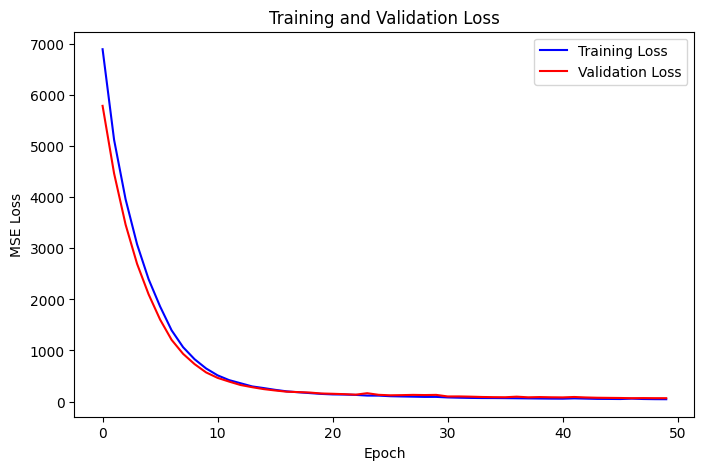

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.show()

166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


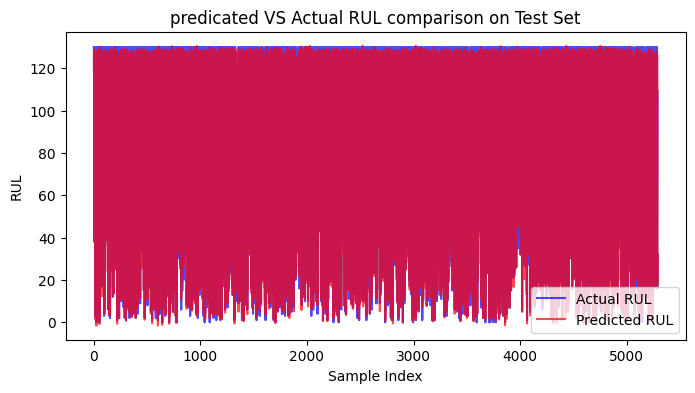

In [10]:
# Verify Model Predictions
val_pred = model.predict(X_test)
val_pred = val_pred.flatten()
plt.figure(figsize=(8, 4))
plt.plot(y_test, label='Actual RUL',alpha = 0.7, color='blue')
plt.plot(val_pred, label='Predicted RUL',alpha = 0.7, color='red')
plt.title("predicated VS Actual RUL comparison on Test Set")
plt.xlabel("Sample Index")
plt.ylabel("RUL")
plt.legend()
plt.show()

In [11]:
# Evaluate on validation set
val_loss, val_mae = model.evaluate(X_test, y_test, verbose=0)
print(f'Validation MSE: {val_loss:.4f}, MAE: {val_mae:.4f}')

# Predict on test set
y_pred = model.predict(X_test).flatten()

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f'Test MSE: {test_mse:.4f}')

Validation MSE: 64.8561, MAE: 5.5631
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Test MSE: 64.8561
